# Denoising Diffusion Probabilistic Models

## 0. Prelim

First, we have a set of $N$ data samples $\mathcal X=\{x_i|i\in \mathbb Z_N \}$, assumed uniquely sampled from an unknown distribution $x_i\sim p_{\text{data}}$.

The MNIST dataset is a good example. In this case, $x_i\in\mathbb R^{784}$.

In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])

import os
os.makedirs('../0.Data/', exist_ok=True)
train_data = datasets.MNIST('../0.Data/', train=True, download=True, transform=transform)
test_data = datasets.MNIST('../0.Data/', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False)

print(f"Loaded {len(train_data)} train, {len(test_data)} test samples")

/data/envs/SML_env/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'Could not load this library: /data/envs/SML_env/lib/python3.10/site-packages/torchvision/image.so'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


Loaded 60000 train, 10000 test samples


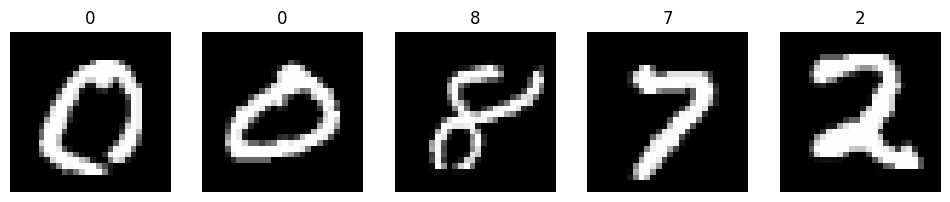

Batch shape: torch.Size([128, 784])
Single image shape: torch.Size([784])


In [2]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
    img = images[i].view(28, 28)  
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'{labels[i]}')
    axes[i].axis('off')
plt.show()

print(f"Batch shape: {images.shape}")
print(f"Single image shape: {images[0].shape}")

## 1. Modelling

Unlike the VAE architecture, DDPMs use a *Fixed* encoder layer, gradually noising the input data from $x_0$ to Gaussian Noise $x_L$. For such process, a linear interpolation encoder is used as below.
$$p(x_i|x_{i-1}):=\mathcal N(x_i;\sqrt{1-\beta^2_i}x_{i-1},\beta^2_i\mathbf I),\quad\text{where }\beta_i\in(0,1)$$
The increasing noise scheduler $\{\beta_i\}_{i=1}^L$ denotes a predetermined encoding process. Such process can easily be defined iteratively as below.
$$x_i=\alpha_ix_{i-1}+\beta_i\epsilon_i,\quad\text{where }\alpha_i=\sqrt{1-\beta_i^2},\space\epsilon_i\sim\mathcal N(0,\mathbf I)$$

Now with this deterministic iterative process per time step, we can denote a closed form distribution at time step $i$ with respect to $x_0$ as below.
$$\mathbb E(x_i)=\alpha_i\mathbb E(x_{i-1})+\beta_i\mathbb E(\epsilon_i)=\Pi_{k=1}^i\alpha_k\space x_0$$
$$\text{Var}(x_i)=(1-\beta_i^2)\text{Var}(x_{i-1})+\beta_i^2=\left[\Pi_{k=1}^i(1-\beta_k^2)\right]\text{Var}(x_0)+\Sigma_{j=1}^i\beta_j^2\Pi_{k=j+1}^i(1-\beta_k^2)=1-\Pi_{k=1}^i\alpha_k^2$$
$$p_i(x_i|x_0)=\mathcal N(x_i;\bar{\alpha}_ix_0,(1-\bar{\alpha}_i^2)\mathbf I),\quad\text{where }\bar\alpha_i :=\Pi_{k=1}^i\sqrt{1-\beta_k^2}=\Pi_{k=1}^i\alpha_k$$
Now, we can sample from an arbitrary time step with an initial data point $x_0$. With an increasing noise scheduler, it is trivial that the prior distribution at time step $L$ must be $p_{\text{prior}}:=\mathcal N(0,\mathbf I)$.

OUr goal now is to approximate the reverse transition kernel from the prior distribution, $p(x_{i-1}|x_i)$. To do this, we would train a network $\phi$ to approximate it via a KL Divergence.
$$\mathbb E_{p_i(x_i)}\left[\mathcal D_{\text{KL}}(p(x_{i-1}|x_i)|p_\phi(x_{i-1}|x_i))\right]$$
However the target distribution is intractable.
$$p(x_{i-1}|x_i)=p(x_i|x_{i-1})\frac{p_{i-1}(x_{i-1})}{p_i(x_i)},\quad\text{where }p_i(x_i)=\int p_i(x_i|x_0)p_{\text{data}}(x_0)dx_0$$
This intractability is solved rather easily, with our presummably uniformly sampled dataset $\mathcal X=\{ \hat x_i\}_{i=1}^D$. Our posterior probability now becomes
$$p(x_{i-1}|x_i,\hat x)=p(x_i|x_{i-1})\frac{p_{i-1}(x_{i-1}|\hat x)}{p_i(x_i|\hat x)}$$
Due to Markovian properties, it is trivial that $p(x_i|x_{i-1},x)=p(x_i|x_{i-1})$ and is a gaussian. Now we get an equivarence between marginal and conditional distributions.
$$\mathbb E_{p_i(x_i)}\mathcal D_{\text{KL}}(p(x_{i-1}|x_i)||p_\phi(x_{i-1}|x_i))=\mathbb E_{p_{\text{data}(\hat x)}}\mathbb E_{p(x_i|\hat x)}\mathcal D_{\text{KL}}(p(x_{i-1}|x_i,\hat x)||p_\phi(x_{i-1}|x_i))+C$$
The reverse conditional transition kernel $p(x_{i-1}|x_i,\hat x)$ has a closed from calculated from $p(x_{i-1}|x_i,\hat x)=p(x_i|x_{i-1})\frac{p_{i-1}(x_{i-1}|\hat x)}{p_i(x_i|\hat x)}$
$$p(x_{i-1}|x_i,\hat x)=\mathcal N(x_{i-1};\frac{\bar \alpha_{i-1}\beta_i^2}{1-\bar\alpha_i^2}\hat x+\frac{(1-\bar\alpha_{i-1}^2)\alpha_i}{1-\bar\alpha_i^2}x_i,\frac{1-\bar\alpha_{i-1}^2}{1-\bar\alpha_i^2}\beta_i^2\mathbf I)$$

Now, our Trainable reverse transition kernel can be modeled with a gaussian as below
$$p_\phi(x_{i-1}|x_i):=\mathcal N(x_{i-1};\mu_\phi(x_i,i),\sigma^2(i)\mathbf I),\quad\text{where }\mu_\phi(\cdot,i):\mathbb R^D\to\mathbb R^D,\space\sigma^2(i)\in\mathbb R_+$$
So the overall loss function with a data sample $x_0$ is
$$\mathcal L_{\text{diffusion}}(x_0,\phi):=\Sigma_{i=1}^L\mathbb E_{p(x_i|x_0)}\left[\mathcal D_{\text{KL}}(p(x_{i-1}|x_i,x_0)||p_\phi(x_{i-1}|x_i))\right]=\Sigma_{i=1}^L\frac{1}{2\sigma^2(i)}||\mu_\phi(x_i,i)-\frac{\bar \alpha_{i-1}\beta_i^2}{1-\bar\alpha_i^2}\hat x+\frac{(1-\bar\alpha_{i-1}^2)\alpha_i}{1-\bar\alpha_i^2}x_i||^2_2+C$$
Averaging over the dataset $\mathcal X$ gives the final loss function of the DDPM architecture.

### Practical Loss

There are 2 types of practical predictions
1. $\epsilon$ prediction
2. $x$ prediction

Let's denote $\mathbb E_{p(x_{i-1}|x_i,x_0)}x_{i-1}$ as $\mu(x_i,x_0,i)=\frac{\bar \alpha_{i-1}\beta_i^2}{1-\bar\alpha_i^2} x_0-\frac{(1-\bar\alpha_{i-1}^2)\alpha_i}{1-\bar\alpha_i^2}x_i$.
We know that $x_i$ follows a gaussian distribution denoted below
$$x_i=\bar\alpha_ix_0+\sqrt{1-\bar\alpha_i^2}\epsilon,\quad\text{where }\epsilon\sim\mathcal N(0,\mathbf I)$$
$$\text{Therefore, }\mu(x_i,x_0,i)=\frac{1}{\alpha_i}(x_i-\frac{1-\alpha_i^2}{\sqrt{1-\bar\alpha_i^2}}\epsilon)$$
Now our training goal of $\mu_\phi(x_i,i)$ can be rewritten as follow.
$$\mu_\phi(x_i,i)=\frac{1}{\alpha_i}(x_i-\frac{1-\alpha_i^2}{\sqrt{1-\bar\alpha_i^2}}\epsilon_\phi(x_i,i))$$
$$||\mu_\phi(x_i,i)-\mu(x_i,x_0,i)||^2_2\space\alpha\space||\epsilon_\phi(x_i,i)-\epsilon||^2_2=\mathbb E_{\epsilon\sim\mathcal N(0,\mathbf I)}||\epsilon_\phi(\bar\alpha_ix_0+\sqrt{1-\bar\alpha^2_i}\epsilon, i)-\epsilon||^2_2$$
Now the final loss is 
$$\mathbb E_i\mathbb E_{x\sim p_{\text{data}}}\mathbb E_{\epsilon\sim\mathcal N(0,\mathbf I)}||\epsilon_\phi(\bar\alpha_ix+\sqrt{1-\bar\alpha^2_i}\epsilon, i)-\epsilon||^2_2$$

A similar simplification may be through a parameterization of the initial sample $x_0$.
$$\mu(x_i,x_0,i)=\frac{\bar \alpha_{i-1}\beta_i^2}{1-\bar\alpha_i^2} x_\phi(x_i,i)-\frac{(1-\bar\alpha_{i-1}^2)\alpha_i}{1-\bar\alpha_i^2}x_i$$
$$\mathcal L:=\mathbb E_i\mathbb E_{x\sim p_{\text{data}}}\mathbb E_{\epsilon\sim\mathcal N(0,\mathbf I)}||x_\phi(\bar\alpha_ix+\sqrt{1-\bar\alpha^2_i}\epsilon, i)-x||^2_2$$